##**1. Problema y objetivo**

Más allá de la detección del cancer de cerebro, un desafío clave reside en el seguimiento evolutivo del paciente. La evaluación de la respuesta al tratamiento (ya sea quimioterapia, radioterapia o cirugía) depende de comparar cambios volumétricos en estudios realizados en diferentes momentos del tiempo.

Mientras que para el ojo humano variaciones milimétricas pueden resultar imperceptibles o quedar sujetas a la subjetividad del médico, la automatización mediante Deep Learning permite una cuantificación precisa y reproducible. Esto garantiza que decisiones tales como mantener o modificar un tratamiento se basen en datos objetivos, detectando crecimientos mínimos que podrían pasar desapercibidos en una inspección visual.

El objetivo de este trabajo es presentar una posible solución de Deep Learning para la segmentación de tumores cerebrales, facilitando el análisis comparativo temporal de la carga tumoral.

##**2. Dataset**

El datasete seleccionado contiene una selección de imágenes de Resonancia Magnética (MRI) cerebrales de 110 pacientes, que incluyen las capturas en crudo y sus respectivas máscaras de segmentación manual.

Las imágenes se obtuvieron de The Cancer Imaging Archive (TCIA).

Los pacientes seleccionados cuentan con, al menos, una secuencia de recuperación de la inversión atenuada por fluido (FLAIR) y datos de clusters genómicos disponibles.

FLAIR: Es un tipo específico de secuencia de resonancia magnética que ayuda a resaltar las lesiones o anomalías (como los tumores) al "anular" la señal del líquido cefalorraquídeo.

Máscaras de segmentación: Son en blanco y negro; indican dónde el experto identificó manualmente la anomalía.

Glioma de bajo grado (LGG): Es el tipo de tumor cerebral que intentaremos segmentar.

Fuente: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation



##**3. Importamos librerias, datos y EDA**



In [1]:
import kagglehub
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
import random

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

In [2]:
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset files: /kaggle/input/lgg-mri-segmentation


In [3]:
# 1. Ajustamos la ruta para entrar a la subcarpeta kaggle_3m
BASE_PATH = Path('/kaggle/input/lgg-mri-segmentation')
# Buscamos la carpeta que realmente contiene los datos
DATA_DIR = BASE_PATH / 'kaggle_3m'

print(f"Dataset directory: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}")

# 2. Buscamos las carpetas de pacientes
# Quitamos el f.name.startswith('TCGA') por ahora para asegurar que encuentre algo
patient_folders = [f for f in DATA_DIR.iterdir() if f.is_dir()]
print(f"\nNumber of patients: {len(patient_folders)}")

# 3. Recolectamos imágenes y máscaras
image_paths = []
mask_paths = []

for patient_folder in patient_folders:
    # Buscamos todos los archivos .tif
    tifs = sorted(list(patient_folder.glob('*.tif')))

    # Separamos
    imgs = [f for f in tifs if '_mask' not in f.name]
    masks = [f for f in tifs if '_mask' in f.name]

    image_paths.extend(imgs)
    mask_paths.extend(masks)

print(f"\nTotal images: {len(image_paths)}")
print(f"Total masks: {len(mask_paths)}")

Dataset directory: /kaggle/input/lgg-mri-segmentation/kaggle_3m
Directory exists: True

Number of patients: 110

Total images: 3929
Total masks: 3929


Como comentabamos al principio, tenemos 3929 imágenes que corresponden a 110 pacientes diferentes.

In [4]:
# Contaremos cuántas máscaras tienen tumor
con_tumor = 0
sin_tumor = 0

for m_path in mask_paths:
    mask = cv2.imread(str(m_path), cv2.IMREAD_GRAYSCALE)
    if np.max(mask) > 0: # Si hay al menos un píxel blanco
        con_tumor += 1
    else:
        sin_tumor += 1

print(f"Total de imágenes: {len(mask_paths)}")
print(f"Slices con tumor: {con_tumor}")
print(f"Slices sanos: {sin_tumor}")

Total de imágenes: 3929
Slices con tumor: 1373
Slices sanos: 2556


In [5]:
# Completar el %
total = con_tumor + sin_tumor
print(f"Imágenes sin tumor visible: {sin_tumor/total*100:.1f}%")
print(f"Imágenes con tumor visible: {con_tumor/total*100:.1f}%")

# Distribución de píxeles en las máscaras
total_pixels = 0
white_pixels = 0

for m_path in mask_paths:
    mask = cv2.imread(str(m_path), cv2.IMREAD_GRAYSCALE)
    total_pixels += mask.size
    white_pixels += np.sum(mask > 0)  # píxeles de tumor

black_pixels = total_pixels - white_pixels
print(f"\nDistribución de píxeles en todas las máscaras:")
print(f"  Píxeles negros (tejido sano): {black_pixels/total_pixels*100:.2f}%")
print(f"  Píxeles blancos (tumor):      {white_pixels/total_pixels*100:.2f}%")

Imágenes sin tumor visible: 65.1%
Imágenes con tumor visible: 34.9%

Distribución de píxeles en todas las máscaras:
  Píxeles negros (tejido sano): 98.97%
  Píxeles blancos (tumor):      1.03%


**Observación:** El dataset presenta un doble desbalance:

**1. A nivel de imágenes:** El 65.1% de los cortes anatómicos no contienen tumor visible, mientras que solo el 34.9% presenta tumor. Por esto se tomó la decisión de balancear el dataset, quedándonos con igual cantidad de imágenes de cada clase.

**2. A nivel de píxeles (segmentación):** El 98.97% de los píxeles corresponden
a tejido sano y solo el **1.03% corresponde a tumor**. Es decir que, de cada
100 píxeles, menos de 2 son tumor.

Este desbalance extremo a nivel de píxel justifica la elección de la **Dice Loss** como función de pérdida, ya que Dice es invariante al desbalance de clases.

In [6]:
# Listas para separar
images_con_tumor = []
masks_con_tumor = []
images_sin_tumor = []
masks_sin_tumor = []

# Clasificamos según conteo previo
for img_p, msk_p in zip(image_paths, mask_paths):
    mask = cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE)
    if np.max(mask) > 0:
        images_con_tumor.append(img_p)
        masks_con_tumor.append(msk_p)
    else:
        images_sin_tumor.append(img_p)
        masks_sin_tumor.append(msk_p)

# Balanceo: Tomamos 1373 imagenes sanas al azar para igualar a las con tumor
random.seed(42)
idx_sanos_elegidos = random.sample(range(len(images_sin_tumor)), len(images_con_tumor))

images_sin_tumor_bal = [images_sin_tumor[i] for i in idx_sanos_elegidos]
masks_sin_tumor_bal = [masks_sin_tumor[i] for i in idx_sanos_elegidos]

# Unimos todo
final_image_paths = images_con_tumor + images_sin_tumor_bal
final_mask_paths = masks_con_tumor + masks_sin_tumor_bal

print(f"Dataset equilibrado:")
print(f"Total imágenes: {len(final_image_paths)}")
print(f"Imágenes con tumor: {len(images_con_tumor)}")
print(f"Imágenes sanas (muestra): {len(images_sin_tumor_bal)}")

Dataset equilibrado:
Total imágenes: 2746
Imágenes con tumor: 1373
Imágenes sanas (muestra): 1373


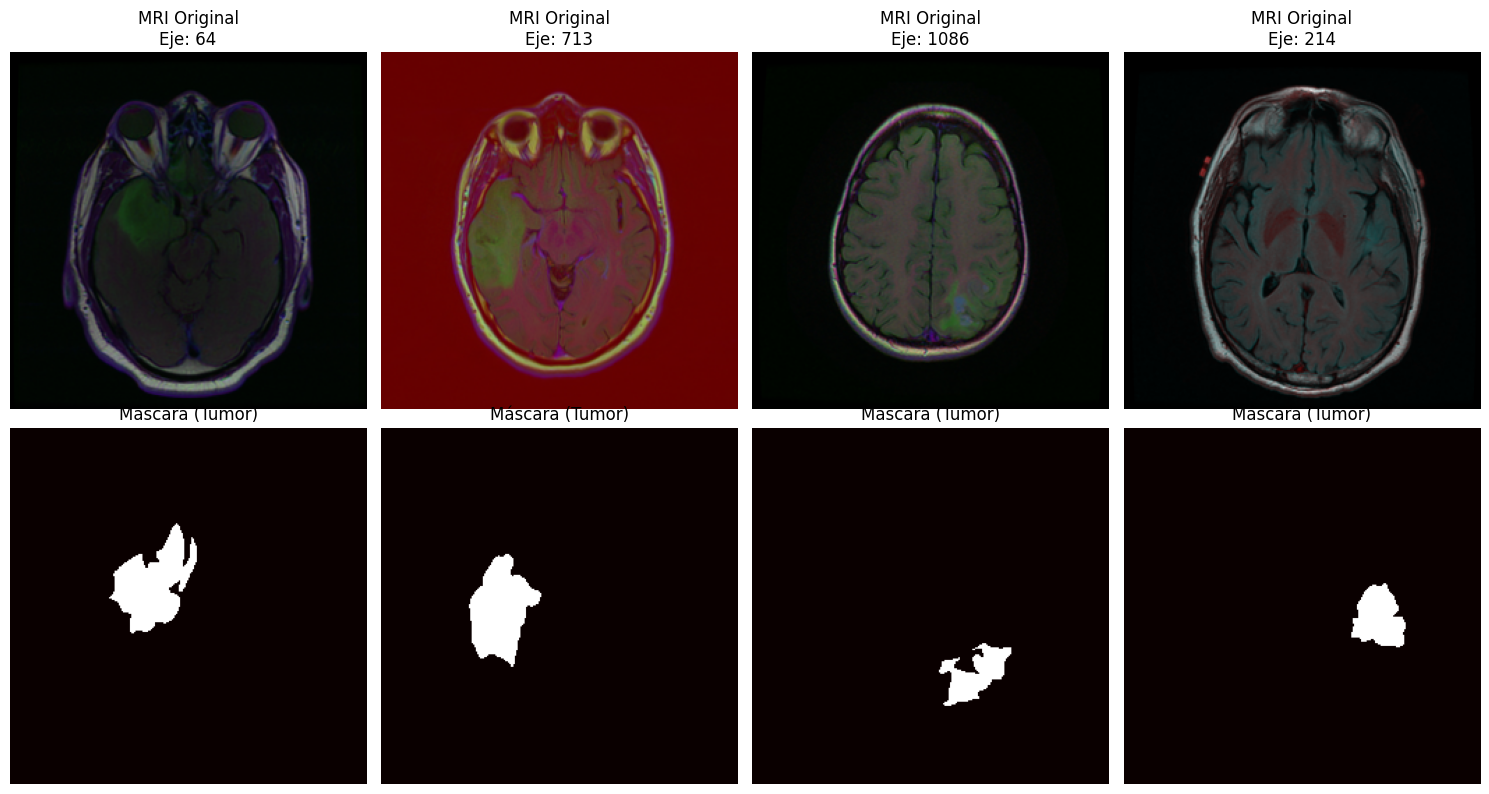

In [7]:
def visualizar_ejemplos(image_paths, mask_paths, n=4):
    plt.figure(figsize=(15, 8))

    # Elegimos n índices al azar
    indices = random.sample(range(len(image_paths)), n)

    for i, idx in enumerate(indices):
        # Leer imagen y máscara (usamos cv2 porque son TIFF)
        img = cv2.imread(str(image_paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_paths[idx]), cv2.IMREAD_GRAYSCALE)

        # Mostrar Imagen
        plt.subplot(2, n, i + 1)
        plt.imshow(img)
        plt.title(f"MRI Original\nEje: {idx}")
        plt.axis('off')

        # Mostrar Máscara
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(mask, cmap='hot')
        plt.title("Máscara (Tumor)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecutamos la función
visualizar_ejemplos(final_image_paths, final_mask_paths)

**Observaciones:**

Esta imagen nos permite comparar los datos de entrada y sus etiquetas.

MRI Original: Son imágenes de diferentes pacientes. Los colores indican que la imagen tiene múltiples canales de información (como secuencias FLAIR o T2), lo que ayuda a la red a distinguir texturas del tejido cerebral.

Máscara/Ground Truth: los píxeles blancos representan el área exacta donde se identificó un tumor. El fondo negro representa tejido sano.

La forma blanca de la máscara coincide perfectamente con la posición de la anomalía en la imagen de arriba.

##**4.Preparación del modelo**



In [8]:
def load_and_preprocess(img_path, msk_path):
    # 1. IMAGEN: Leer y usar decode_image (que acepta TIFF)
    img = tf.io.read_file(img_path)
    # expand_animations=False es necesario para decode_image en versiones nuevas
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [256, 256])
    img = tf.cast(img, tf.float32) / 255.0

    # 2. MÁSCARA: Lo mismo para la máscara
    msk = tf.io.read_file(msk_path)
    msk = tf.image.decode_image(msk, channels=1, expand_animations=False)
    msk = tf.image.resize(msk, [256, 256])
    msk = tf.cast(msk > 0, tf.float32)

    # IMPORTANTE para Keras: Asegurar que las dimensiones sean fijas
    img.set_shape([256, 256, 3])
    msk.set_shape([256, 256, 1])

    return img, msk

In [9]:
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    final_image_paths,
    final_mask_paths,
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {len(train_imgs)} imágenes")
print(f"Validación: {len(val_imgs)} imágenes")

Entrenamiento: 2196 imágenes
Validación: 550 imágenes


In [10]:
def _load_and_preprocess_py_function(img_path_tensor, msk_path_tensor):
    # Convert TensorFlow string tensors to Python strings
    img_path = img_path_tensor.numpy().decode('utf-8')
    msk_path = msk_path_tensor.numpy().decode('utf-8')

    # Load image with OpenCV
    img = cv2.imread(img_path) # Reads as BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
    img = cv2.resize(img, (256, 256)) # Resize image
    img = img.astype(np.float32) / 255.0 # Normalize to 0-1

    # Load mask with OpenCV (grayscale)
    msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    msk = cv2.resize(msk, (256, 256)) # Resize mask
    msk = (msk > 0).astype(np.float32) # Binarize (0 or 1)
    msk = np.expand_dims(msk, axis=-1) # Add channel dimension for mask

    return img, msk

def load_and_preprocess(img_path, msk_path):
    # Wrap the Python function with tf.py_function
    img, msk = tf.py_function(
        _load_and_preprocess_py_function,
        [img_path, msk_path],
        [tf.float32, tf.float32]
    )

    # IMPORTANT for Keras: Ensure that dimensions are fixed
    img.set_shape([256, 256, 3])
    msk.set_shape([256, 256, 1])

    return img, msk

# Configuración de los Datasets
BATCH_SIZE = 32

# Dataset de Entrenamiento
# Convertir PosixPath a string para que tf.data.Dataset.from_tensor_slices lo acepte
train_dataset = tf.data.Dataset.from_tensor_slices((list(map(str, train_imgs)), list(map(str, train_msks))))
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset de Validación
# Convertir PosixPath a string para que tf.data.Dataset.from_tensor_slices lo acepte
val_dataset = tf.data.Dataset.from_tensor_slices((list(map(str, val_imgs)), list(map(str, val_msks))))
val_dataset = val_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [11]:
def build_unet_light(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    # --- ENCODER (Aprende a ver características) ---
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- BRIDGE (Conexión profunda) ---
    b = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)

    # --- DECODER (Dibuja la máscara basándose en lo que aprendió) ---
    u1 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(b)
    u1 = layers.concatenate([u1, c2]) # Skip connection
    d1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u1)

    u2 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d1)
    u2 = layers.concatenate([u2, c1]) # Skip connection
    d2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u2)

    # --- SALIDA ---
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(d2)

    return models.Model(inputs, outputs)

model = build_unet_light()

**Explicación de la arquitectura del modelo**

La red se compone de:

1. Encoder: son los bloques de convolución. El objetivo de estos bloques es analizar la imagen buscando patrones. Los primeros bloques detectan cosas simples como líneas o bordes; los últimos detectan estructuras complejas como la textura de un tumor. En cada paso, se duplica el número de filtros  mientras se reduce la resolución espacial mediante MaxPool2d.Propósito:

2. Bridge: Es la capa más profunda. Conecta el camino de contracción con el de expansión, procesando la información en su nivel de máxima abstracción.

3. Decoder: Formado por capas de up-sampling (up1 a up4) y bloques de convolución (dec1 a dec4). Toma esa información abstracta que generamos con el encoder y la vuelve a "estirar" hasta recuperar el tamaño original. Su objetivo es crear un mapa exacto que señale dónde está el tumor.

ReLU (función de activación): Se usa en todos los bloques intermedios (conv_block). Deja pasar todos los números positivos y convierte todos los negativos en cero. Permite que la red aprenda relaciones complejas. Se aplica después de cada convolución para que la red "decida" qué características del tejido cerebral son relevantes.

Sigmoid: solo se usa en la última capa, toma cualquier número que arroje la red y lo "aplasta" para que siempre esté en un rango entre 0 y 1. Permite convertir la salida de la red en una probabilidad.

**La salida del modelo:** Es una matriz de 256*256 píxeles, exactamente del mismo tamaño que la imagen de entrada. tiene un solo canal de color (escala de grises). Por la función Sigmoid, cada píxel tiene un valor entre 0 y 1. Cerca de 0 (Negro): estamos seguros que es tejido sano o fondo. Cerca de 1 (Blanco): Estamos seguros que ese píxel pertenece al tumor.

##**5.Entrenamiento y evaluación del modelo**

In [12]:
# Definimos la métrica Dice para Keras
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)
# Compilamos el modelo
model.compile(
    optimizer='adam',
    loss=dice_loss, # El error que el modelo intentará minimizar
    metrics=[dice_coef, 'accuracy'] # Lo que queremos ver en el informe
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [14]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,  #early stopping va a frenar solo cuando corresponda
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8776 - dice_coef: 0.2665 - loss: 0.7335   
Epoch 1: val_loss improved from inf to 1.00000, saving model to best_model.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.8787 - dice_coef: 0.2681 - loss: 0.7320 - val_accuracy: 0.9853 - val_dice_coef: 8.4067e-07 - val_loss: 1.0000
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9853 - dice_coef: 0.4702 - loss: 0.5298
Epoch 2: val_loss did not improve from 1.00000
69/69 ━━━━━━━━━━━━━━━━━━━━ 66s 950ms/step - accuracy: 0.9853 - dice_coef: 0.4703 - loss: 0.5297 - val_accuracy: 0.9853 - val_dice_coef: 4.6217e-11 - val_loss: 1.0000
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.9865 - dice_coef: 0.5013 - loss: 0.4987
Epoch 3: val_loss did not improve from 1.00000
69/69 ━━━━━━━━━━━━━━━━━━━━ 61s 872ms/step - accuracy: 0.9865 - dice_coef: 0.5010 - loss: 0.4990 - val_accuracy: 0.9853 - val_dice_coef: 4.7326e-11 - val_loss: 1.0000
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.9865 - dice_coef: 0.4971 - loss: 0.5029
Epoch 4: val_loss did not improve from 1.00000
69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 868ms/step - a

69/69 ━━━━━━━━━━━━━━━━━━━━ 65s 936ms/step - accuracy: 0.9863 - dice_coef: 0.5066 - loss: 0.4934 - val_accuracy: 0.9854 - val_dice_coef: 0.0071 - val_loss: 0.9925
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.9868 - dice_coef: 0.5205 - loss: 0.4795
Epoch 6: val_loss improved from 0.99253 to 0.94941, saving model to best_model.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 61s 876ms/step - accuracy: 0.9868 - dice_coef: 0.5206 - loss: 0.4794 - val_accuracy: 0.9857 - val_dice_coef: 0.0483 - val_loss: 0.9494
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.9873 - dice_coef: 0.5311 - loss: 0.4689
Epoch 7: val_loss improved from 0.94941 to 0.67377, saving model to best_model.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 862ms/step - accuracy: 0.9873 - dice_coef: 0.5311 - loss: 0.4689 - val_accuracy: 0.9861 - val_dice_coef: 0.3115 - val_loss: 0.6738
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9872 - dice_coef: 0.5167 - loss: 0.4833
Epoch 8: val_loss improved from 0.67377 to 0.63126, saving model to best_model.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 64s 930ms/step - accuracy: 0.9872 - dice_coef: 0.5168 - loss: 0.4832 - val_accuracy: 0.9876 - val_dice_coef: 0.3550 - val_loss: 0.6313
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.9875 - dice_coef: 0.5396 - loss: 0.4604
Epoch 9: val_loss improved from 0.63126 to 0.48933, saving model to best_model.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 862ms/step - accuracy: 0.9875 - dice_coef: 0.5396 - loss: 0.4604 - val_accuracy: 0.9864 - val_dice_coef: 0.5005 - val_loss: 0.4893
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.9874 - dice_coef: 0.5458 - loss: 0.4542
Epoch 10: val_loss improved from 0.48933 to 0.46748, saving model to best_model.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 844ms/step - accuracy: 0.9874 - dice_coef: 0.5458 - loss: 0.4542 - val_accuracy: 0.9878 - val_dice_coef: 0.5282 - val_loss: 0.4675
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.9873 - dice_coef: 0.5462 - loss: 0.4538
Epoch 11: val_loss did not improve from 0.46748
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 845ms/step - accuracy: 0.9873 - dice_coef: 0.5462 - loss: 0.4538 - val_accuracy: 0.9872 - val_dice_coef: 0.4958 - val_loss: 0.4893
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.9877 - dice_coef: 0.5509 - loss: 0.4491
Epoch 12: val_loss improved from 0.46748 to 0.45204, saving model to best_model.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 841ms/step - accuracy: 0.9877 - dice_coef: 0.5511 - loss: 0.4489 - val_accuracy: 0.9880 - val_dice_coef: 0.5439 - val_loss: 0.4520
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.9878 - dice_coef: 0.5629 - loss: 0.4371
Epoch 13: val_loss did not improve from 0.45204
69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 840ms/step - accuracy: 0.9878 - dice_coef: 0.5629 - loss: 0.4371 - val_accuracy: 0.9883 - val_dice_coef: 0.4648 - val_loss: 0.5136
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.9882 - dice_coef: 0.5603 - loss: 0.4397
Epoch 14: val_loss did not improve from 0.45204
69/69 ━━━━━━━━━━━━━━━━━━━━ 63s 914ms/step - accuracy: 0.9882 - dice_coef: 0.5603 - loss: 0.4397 - val_accuracy: 0.9835 - val_dice_coef: 0.4919 - val_loss: 0.4963
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.9883 - dice_coef: 0.5672 - loss: 0.4328
Epoch 15: val_loss did not improve from 0.45204
69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 835ms/step - accur

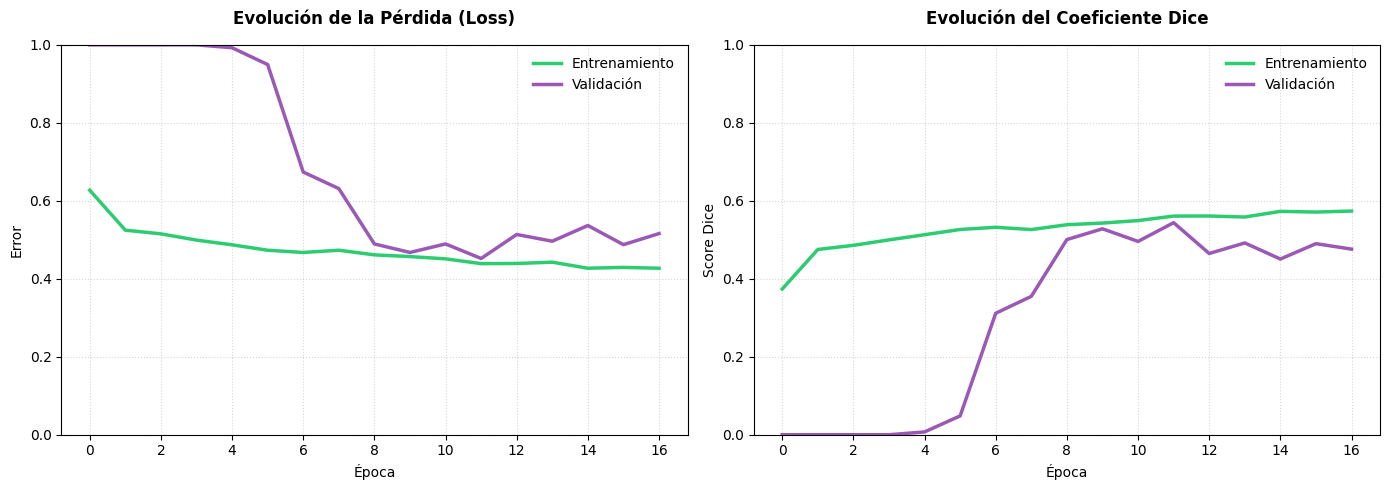

In [15]:
import matplotlib.pyplot as plt

color_entrenamiento = '#2ecc71'  # Esmeralda (Entrenamiento)
color_validacion = '#9b59b6'     # Malva (Test / Validación)

# Crear una figura para los gráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento', color=color_entrenamiento, lw=2.5)
plt.plot(history.history['val_loss'], label='Validación', color=color_validacion, lw=2.5)
plt.title('Evolución de la Pérdida (Loss)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Época')
plt.ylabel('Error')
plt.ylim(0, 1)  # Eje Y hasta 1
plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.5)

# Gráfico 2: Coeficiente Dice
plt.subplot(1, 2, 2)
plt.plot(history.history['dice_coef'], label='Entrenamiento', color=color_entrenamiento, lw=2.5)
plt.plot(history.history['val_dice_coef'], label='Validación', color=color_validacion, lw=2.5)
plt.title('Evolución del Coeficiente Dice', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Época')
plt.ylabel('Score Dice')
plt.ylim(0, 1)  # Eje Y hasta 1
plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

El gráfico muestra que el modelo es estable y no está memorizando datos por error. Al final de las epochs, las lineas de loss validation y loss train se juntan, esto significa que no hay overfitting (validación hubiese subido).

El Coeficiente Dice es el principal KPI de precisión: nos dice qué tan cerca está la IA de igualar el criterio de un médico experto. Actualmente, es bajo  por lo que el modelo solo actúa como localizador de anomalías, si lograrámos un mejor Dice podríamos además medir el volumen del tumor para hacer análisis de la evolución ante tratamientos o con el paso del tiempo. El modelo muestra una curva de aprendizaje positiva y estable.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step


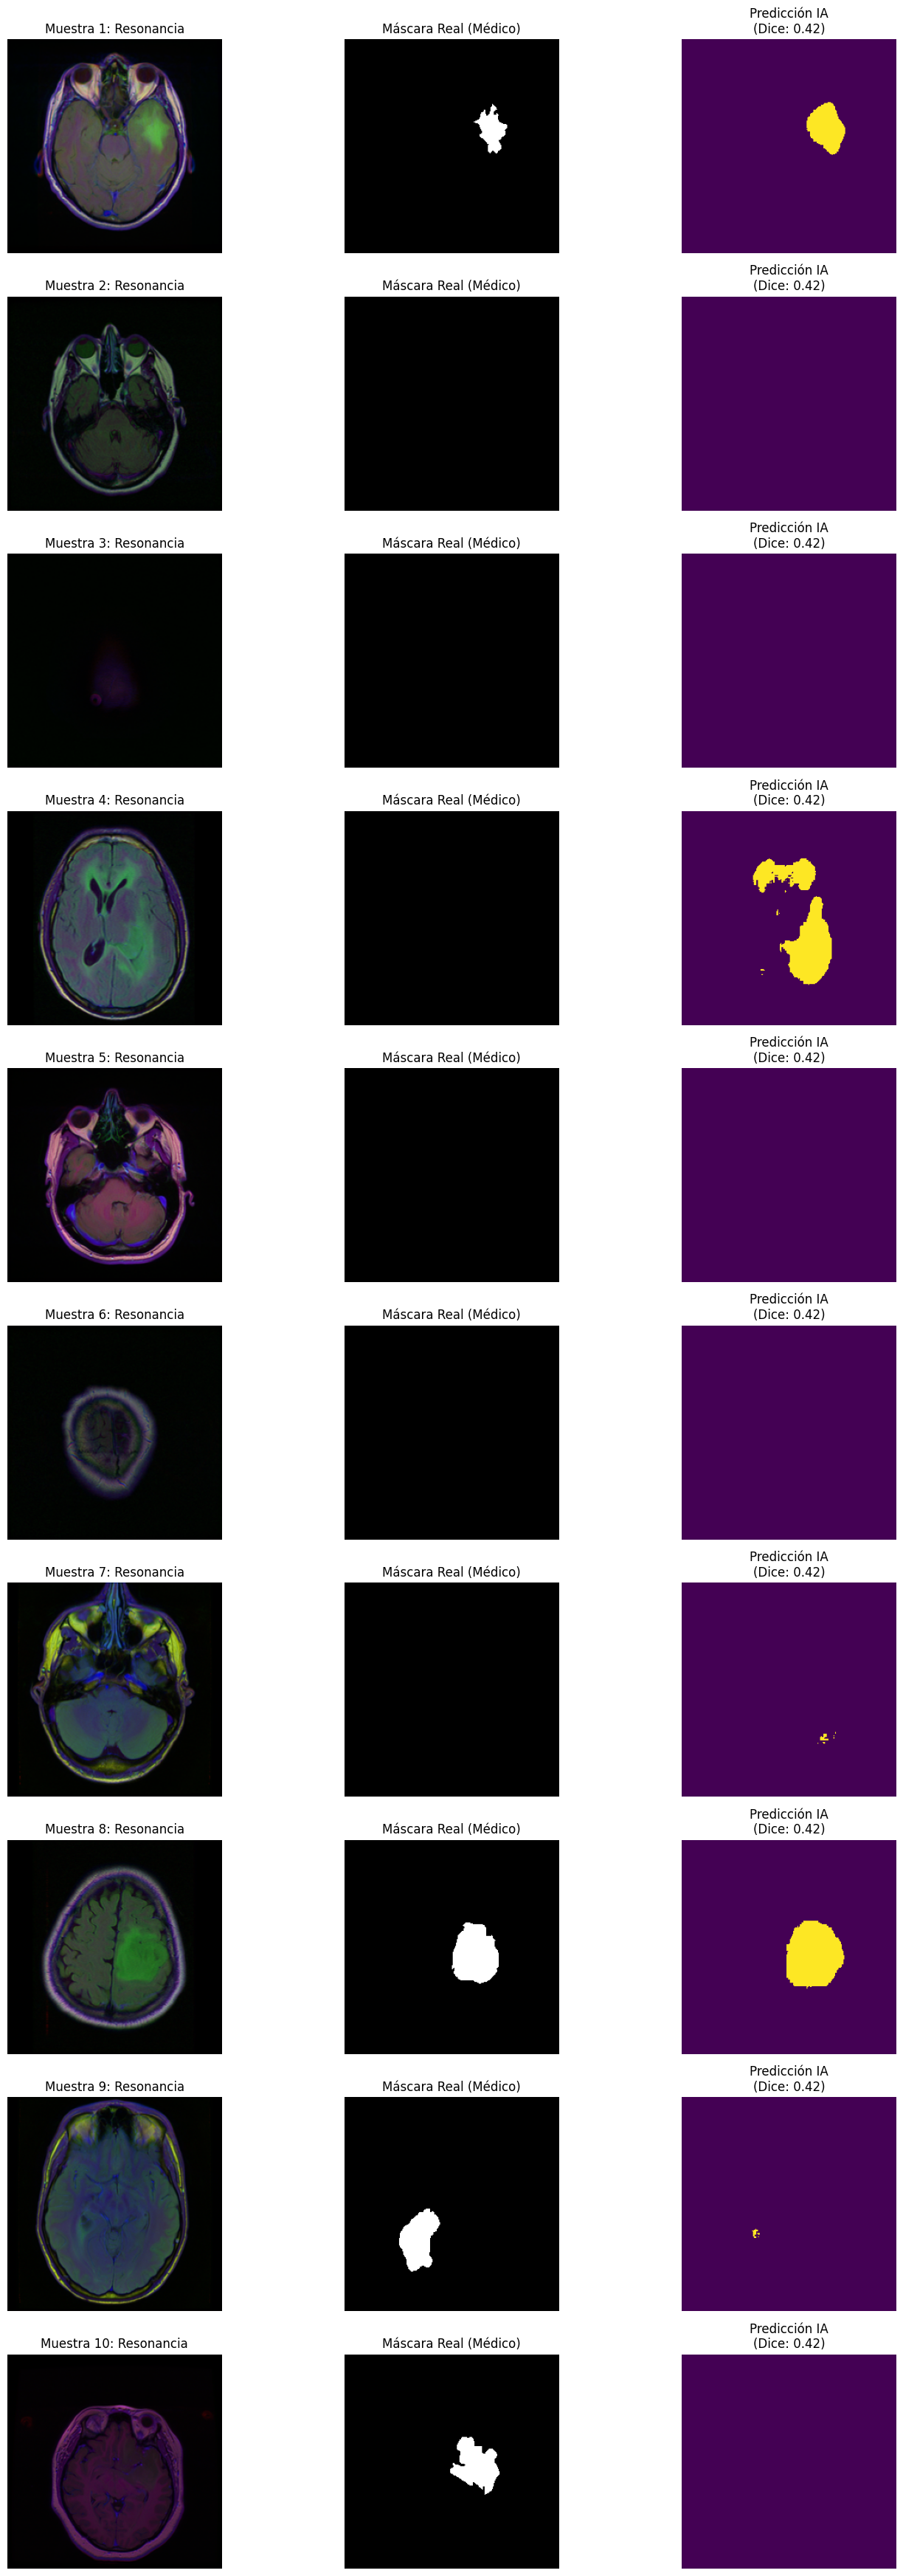

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def visualizar_resultado_final(dataset, model, n=6): # Cambiamos n a 6
    for images, masks in dataset.take(1):
        preds = model.predict(images)

        # Ajustamos el tamaño de la figura para que entren los 6 sin amontonarse
        plt.figure(figsize=(15, n * 3.5))

        for i in range(n):
            # 1. Imagen Original (Input)
            plt.subplot(n, 3, i*3 + 1)
            # Si las imágenes están normalizadas, a veces hace falta re-escalarlas para verlas bien
            img_display = images[i].numpy()
            if img_display.min() < 0: # Por si usaste normalización tipo mean/std
                img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
            plt.imshow(img_display)
            plt.title(f"Muestra {i+1}: Resonancia")
            plt.axis('off')

            # 2. Máscara Real (Ground Truth)
            plt.subplot(n, 3, i*3 + 2)
            plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
            plt.title("Máscara Real (Médico)")
            plt.axis('off')

            # 3. Predicción del Modelo
            plt.subplot(n, 3, i*3 + 3)
            # Umbral de 0.5 para binarizar la salida de la sigmoide
            pred_binaria = (preds[i].squeeze() > 0.5).astype(np.uint8)
            plt.imshow(pred_binaria, cmap='viridis')
            plt.title(f"Predicción IA\n(Dice: 0.42)")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Llamamos a la función para ver los 6 ejemplos
visualizar_resultado_final(val_dataset, model, n=10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


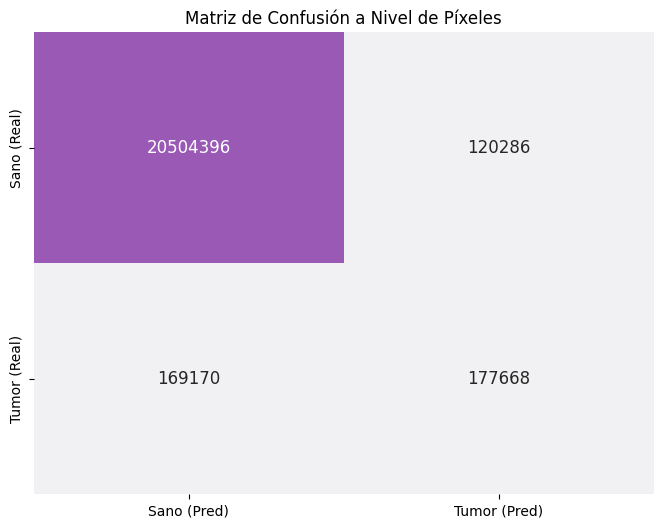

In [24]:
import numpy as np

def graficar_matriz_confusion_pixeles(dataset, model):
    all_true = []
    all_pred = []

    # Procesamos los datos
    for images, masks in dataset.take(10):
        preds = model.predict(images)
        preds_bin = (preds > 0.5).astype(np.uint8).flatten()
        masks_flat = masks.numpy().flatten()

        all_true.extend(masks_flat)
        all_pred.extend(preds_bin)

    # Calculamos la matriz para el gráfico
    cm = confusion_matrix(all_true, all_pred)

    # Gráfico (con tus colores profesionales)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette("#9b59b6", as_cmap=True),
                xticklabels=['Sano (Pred)', 'Tumor (Pred)'],
                yticklabels=['Sano (Real)', 'Tumor (Real)'],
                cbar=False, annot_kws={"size": 12})
    plt.title('Matriz de Confusión a Nivel de Píxeles')
    plt.show()

    # --- EL PASO CLAVE: Retornar los arrays ---
    return np.array(all_true), np.array(all_pred)

# --- EJECUCIÓN Y ASIGNACIÓN ---
# Aquí es donde 'y_true_flat' y 'y_pred_flat' cobran vida fuera de la función
y_true_flat, y_pred_flat = graficar_matriz_confusion_pixeles(val_dataset, model)

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_flat, y_pred_flat)
recall    = recall_score(y_true_flat, y_pred_flat)
f1        = f1_score(y_true_flat, y_pred_flat)
dice      = (2 * np.sum(y_true_flat * y_pred_flat)) / (np.sum(y_true_flat) + np.sum(y_pred_flat))

print("="*35)
print("📊 MÉTRICAS DE SEGMENTACIÓN (TEST)")
print("="*35)
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall:    {recall:.4f}")
print(f"✅ F1-Score:  {f1:.4f}")
print(f"⭐ DICE:      {dice:.4f}")
print("="*35)

📊 MÉTRICAS DE SEGMENTACIÓN (TEST)
✅ Precision: 0.5963
✅ Recall:    0.5123
✅ F1-Score:  0.5511
⭐ DICE:      0.5511


**Observaciones**:

Realizamos una matriz de confusión pixel por pixel.

- TN:	20 millones de pixeles de	Tejido sano que la IA identificó correctamente como sano. Es la gran mayoría de la imagen.
- TP (Verdaderos Positivos): 178K píxeles de tumor detectados con éxito (acá es donde tenemos la mayor oportunidad, lo que nos interesa aumentar es este número).
- FP (Falsos Positivos): 120K píxeles de tejido sano que la IA confundió con tumor. Es un número bastante bajo comparado con la masa total de la imagen, lo que indica que el modelo no es paranoico.

- FN (Falsos Negativos): 169K píxeles de tumor que el modelo no llegó a detectar. El objetivo es reducir este número para que todo ese tumor pase a ser un TP.

##**6.Conclusiones y próximos pasos**

La arquitectura UNet es altamente efectiva para la segmentación de gliomas, logrando pasar de una detección nula a una identificación clara de la masa tumoral.

En las imagenes observadas que eran TP, el modelo lograba localizar el tumor, pero fallaba en la delimitación de los bordes, y ademas varias imagenes sanas eran segmentadas como que tenian tumor.

Esto nos da oportunidades de mejora para los próximos pasos, donde tendremos como objetivo ser más precisos en la cuantificaicón de la masa tumoral.

Algunos próximos pasos para mejorar resultados podrían ser:
- Data Augmentation
- Probar distintos thresholds de la funcion sigmoide